# Assignment 3

In [2]:
# import graph_tool.all as gt
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

In [6]:
g = gt.collection.ns["polblogs"]
g = gt.extract_largest_component(g, directed=False)

In [7]:
# https://graph-tool.skewed.de/static/docs/stable/autosummary/graph_tool.inference.minimize_blockmodel_dl.html
state_ndc = gt.minimize_blockmodel_dl(
    g,
    state=gt.BlockState,
    state_args=dict(deg_corr=False),
    multilevel_mcmc_args=dict(B_min=2, B_max=2)
)

state_dc = gt.minimize_blockmodel_dl(
    g,
    state=gt.BlockState,
    state_args=dict(deg_corr=True),
    multilevel_mcmc_args=dict(B_min=2, B_max=2)
)
print("Non-degree-corrected blocks:", state_ndc.get_nonempty_B())
print("Degree-corrected blocks:", state_dc.get_nonempty_B())


Non-degree-corrected blocks: 2
Degree-corrected blocks: 2


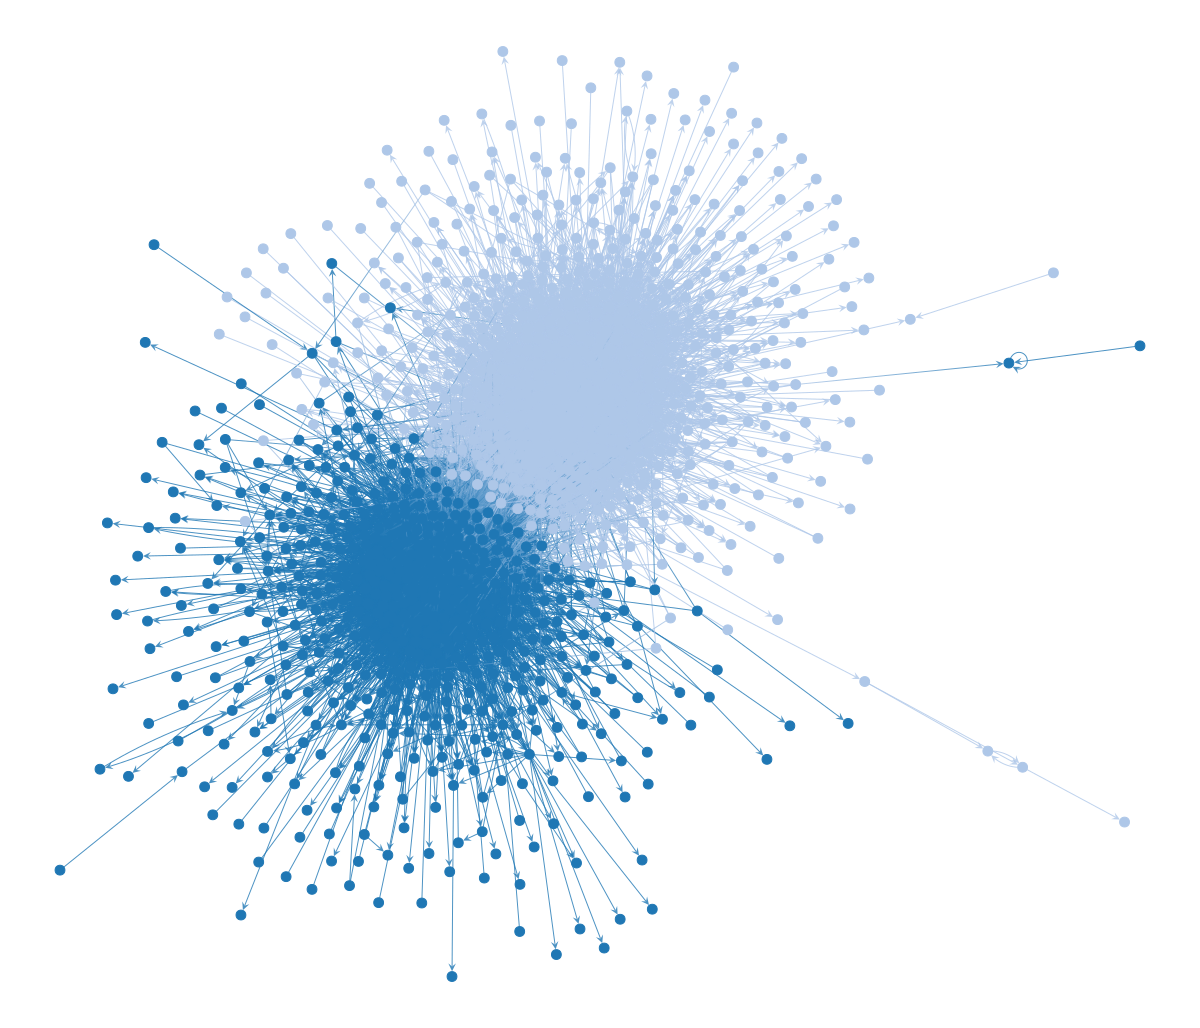

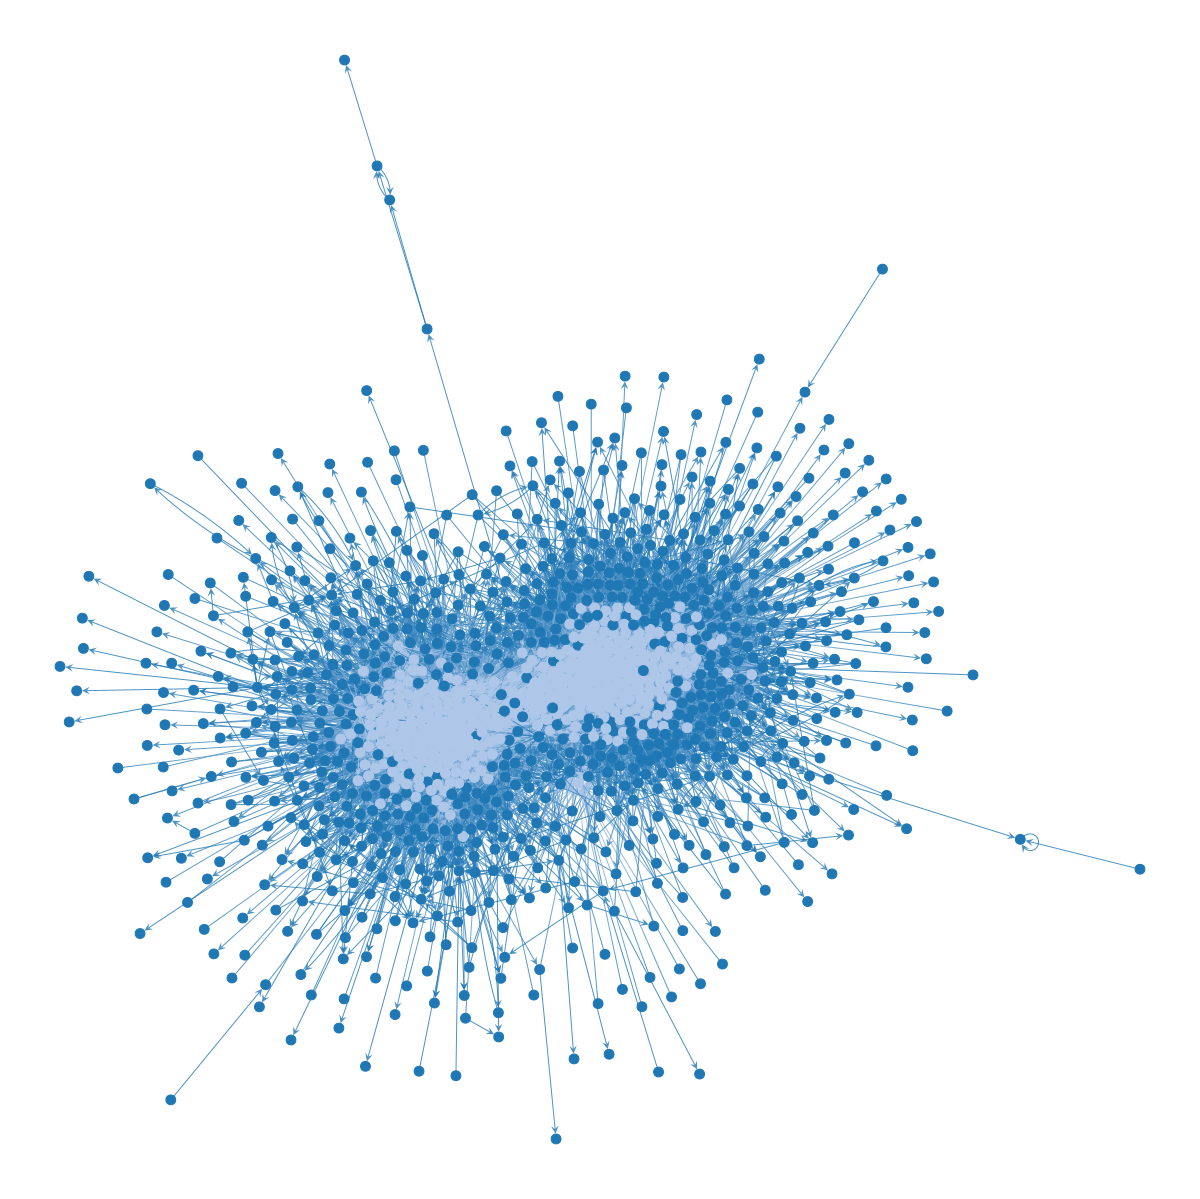

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7f05c382aed0, at 0x7f05c2b15490>

In [11]:
state_dc.draw()
state_ndc.draw()

In [15]:
dl_dc = state_dc.entropy()
dl_ndc = state_ndc.entropy()
print("degree-corrected description length:",dl_dc)
print("Non-degree-corrected description length:",dl_ndc)


degree-corrected description length: 63431.89569438755
Non-degree-corrected description length: 83180.5653687696


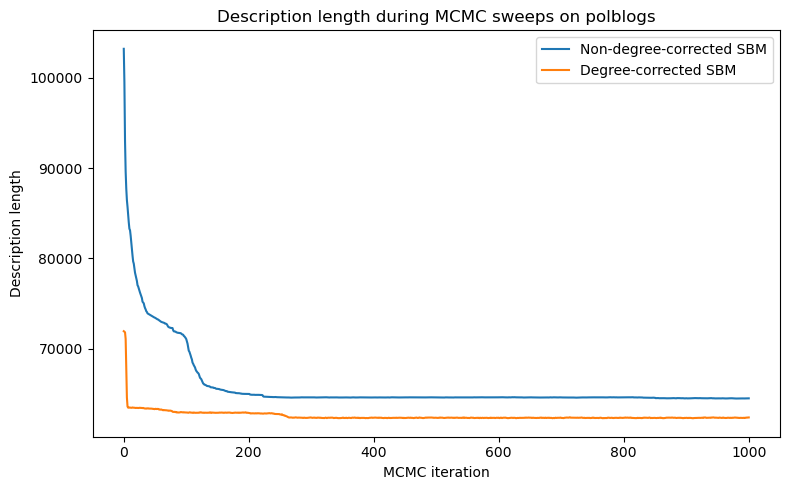

In [17]:
state_ndc2 = gt.BlockState(g, B=2, deg_corr=False)
state_dc2  = gt.BlockState(g, B=2, deg_corr=True)
dl_ndc = [state_ndc2.entropy()]
dl_dc  = [state_dc2.entropy()]

for _ in range(1000):
    state_ndc2.mcmc_sweep(niter=1)
    state_dc2.mcmc_sweep(niter=1)
    
    dl_ndc.append(state_ndc2.entropy())
    dl_dc.append(state_dc2.entropy())

plt.figure(figsize=(8, 5))
plt.plot(dl_ndc, label="Non-degree-corrected SBM")
plt.plot(dl_dc, label="Degree-corrected SBM")
plt.xlabel("MCMC iteration")
plt.ylabel("Description length")
plt.title("Description length during MCMC sweeps on polblogs")
plt.legend()
plt.tight_layout()
plt.show()

## Question 2

In [5]:
G = nx.karate_club_graph()

degree = dict(G.degree())
clustering = nx.clustering(G)
pagerank = nx.pagerank(G)
betweenness = nx.betweenness_centrality(G)

y = []
attendance = []
tenure = []
for node in G.nodes():
    club = G.nodes[node]["club"]
    y.append(0 if club == "Mr. Hi" else 1)
    
y = np.array(y)
for label in y:
    if label == 0:
        attendance.append(np.random.normal(50,10))
        tenure.append(np.random.normal(3,1)) 
    else:           
        attendance.append(np.random.normal(70,10))
        tenure.append(np.random.normal(6,1))

In [6]:
X = pd.DataFrame({
    "degree":[degree[i] for i in G.nodes()],
    "clustering":[clustering[i] for i in G.nodes()],
    "pagerank":[pagerank[i] for i in G.nodes()],
    "betweenness":[betweenness[i] for i in G.nodes()],
    "attendance":attendance,
    "tenure":tenure
})

In [24]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def cal_acc(X,y):
    accuracy_list = []
    F1_list = []
    for seed in range(50):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.2,
            stratify=y,
            random_state=seed
        )
        model = RandomForestClassifier()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        F1 = f1_score(y_test, y_pred, average="macro")
    
        accuracy_list.append(acc)
        F1_list.append(F1)
    
    acc_mean = np.mean(accuracy_list)
    acc_std = np.std(accuracy_list)
    
    F1_mean = np.mean(F1_list)
    F1_std = np.std(F1_list)
    
    print("Accuracy: %.3f ± %.3f" % (acc_mean, acc_std))
    print("Macro-F1: %.3f ± %.3f" % (F1_mean, F1_std))
cal_acc(X,y)

Accuracy: 0.960 ± 0.070
Macro-F1: 0.959 ± 0.073


In [13]:
seed = 11

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=seed
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [14]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3 0]
 [0 4]]


In [22]:
feature_names = ["degree","clustering","pagerank","betweenness","attendance","tenure"]
imp_df = pd.DataFrame({"feature": feature_names,"importance": model.feature_importances_}).sort_values("importance", ascending=False)
print(imp_df)

       feature  importance
5       tenure    0.468601
4   attendance    0.322603
1   clustering    0.075350
2     pagerank    0.056952
3  betweenness    0.048237
0       degree    0.028257


In [26]:
X_new = pd.DataFrame({
    "degree":[degree[i] for i in G.nodes()],
    "betweenness":[betweenness[i] for i in G.nodes()],
    "attendance":attendance,
    "tenure":tenure
})

In [27]:
cal_acc(X_new,y)

Accuracy: 0.943 ± 0.086
Macro-F1: 0.940 ± 0.091


## Question 3

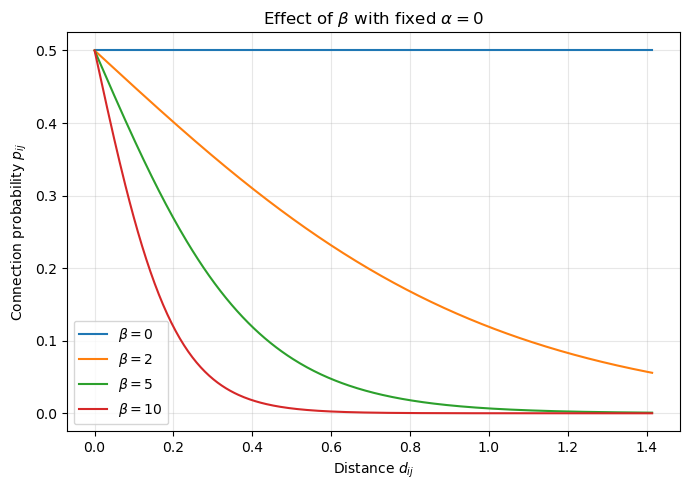

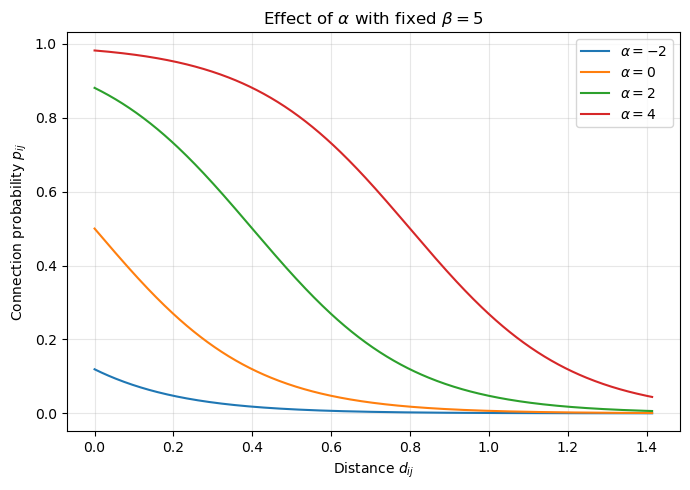

In [91]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

d = np.linspace(0, np.sqrt(2), 400)

alpha_fixed = 0
beta_values = [0, 2, 5, 10]

plt.figure(figsize=(7,5))
for beta in beta_values:
    p = sigmoid(alpha_fixed - beta * d)
    plt.plot(d, p, label=rf'$\beta={beta}$')

plt.xlabel("Distance $d_{ij}$")
plt.ylabel(r"Connection probability $p_{ij}$")
plt.title(r"Effect of $\beta$ with fixed $\alpha=0$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

beta_fixed = 5
alpha_values = [-2, 0, 2, 4]

plt.figure(figsize=(7,5))
for alpha in alpha_values:
    p = sigmoid(alpha - beta_fixed * d)
    plt.plot(d, p, label=rf'$\alpha={alpha}$')

plt.xlabel("Distance $d_{ij}$")
plt.ylabel(r"Connection probability $p_{ij}$")
plt.title(r"Effect of $\alpha$ with fixed $\beta=5$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
from scipy.spatial.distance import pdist, squareform
N = 300
pos = np.random.rand(N,2)
D = squareform(pdist(pos))

def sigmoid(x):
    return 1/(1+np.exp(-x))

def generate_graph(alpha, beta):
    G = nx.Graph()
    G.add_nodes_from(range(N))
    
    for i in range(N):
        for j in range(i+1,N):
            p = sigmoid(alpha - beta*D[i,j])
            if np.random.rand() < p:
                G.add_edge(i,j)       
    return G
    
def compute_metrics(G):
    m = G.number_of_edges()
    avg_k = 2*m/N
    dist_sum = 0

    for u,v in G.edges():
        dist_sum += D[u,v]
        
    avg_edge_dist = dist_sum / m if m > 0 else 0
    return m, avg_k, avg_edge_dist

alpha = 0
beta_small = 0.5
beta_large = 5
G_small = generate_graph(alpha, beta_small)
G_large = generate_graph(alpha, beta_large)
m_s, k_s, d_s = compute_metrics(G_small)
m_l, k_l, d_l = compute_metrics(G_large)

print("Small beta network")
print("m =", m_s)
print("<k> =", k_s)
print("<d_edge> =", d_s)

print("\nLarge beta network")
print("m =", m_l)
print("<k> =", k_l)
print("<d_edge> =", d_l)

Small beta network
m = 19621
<k> = 130.80666666666667
<d_edge> = 0.4944788329230725

Large beta network
m = 5096
<k> = 33.973333333333336
<d_edge> = 0.30247432790545625


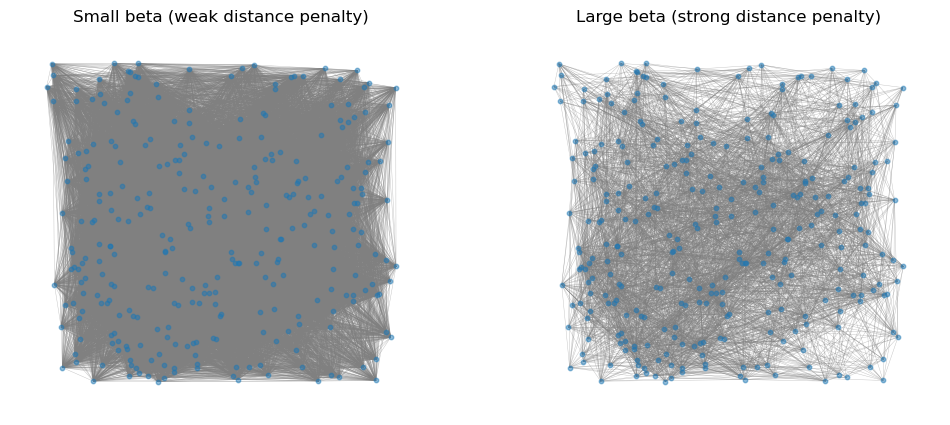

In [13]:
pos_dict = {i:pos[i] for i in range(N)}

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
nx.draw(G_small,pos_dict,node_size=10,edge_color="gray", alpha = 0.5, width = 0.3)
plt.title("Small beta (weak distance penalty)")

plt.subplot(1,2,2)
nx.draw(G_large,pos_dict,node_size=10,edge_color="gray", alpha = 0.5, width = 0.3 )
plt.title("Large beta (strong distance penalty)")

plt.show()

## Question 4

In [63]:
import osmnx as ox
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

def plot_buildings(center_point, radius=3219):
    tags = {"building": True}

    gdf = ox.features_from_point(center_point, tags=tags, dist=radius)
    gdf_proj = ox.projection.project_gdf(gdf)

    bldg_colors = dict(zip(
        gdf_proj['building'].unique(),
        plt.cm.tab20(np.linspace(0,1,gdf_proj['building'].nunique()))
    ))
    bcs = [bldg_colors[i] for i in gdf_proj['building'].values]

    fig, ax = ox.plot_footprints(
        gdf_proj,
        bgcolor='white',
        color=bcs,
        dpi=400,
        show=False,
        close=False
    )
    center_gdf = gpd.GeoDataFrame(
        geometry=[Point(center_point[1], center_point[0])],
        crs="EPSG:4326"
    )
    center_proj = center_gdf.to_crs(gdf_proj.crs)

    x = center_proj.geometry.x.iloc[0]
    y = center_proj.geometry.y.iloc[0]
    ax.scatter(
        x,
        y,
        c="black",
        s=30,
        marker="o",
        label="Center"
    )

    ax.legend()
    plt.title(f"Building Footprints Around {center_point} ({radius} Radius)")
    plt.show()
    print("Buildings:", len(gdf))

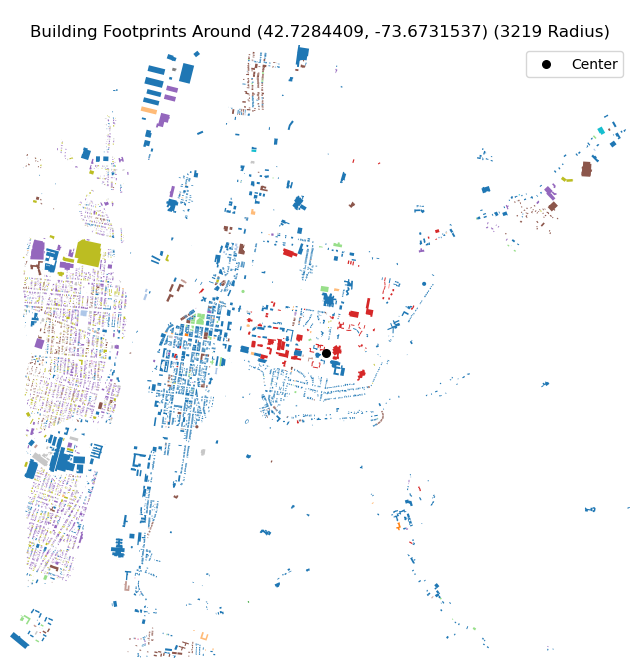

Buildings: 8396
Number of nodes (N): 1607
Number of edges (M): 4077


In [85]:
center_point = ox.geocode("1999 Burdett Ave, Troy, NY")
plot_buildings(center_point)
G1 = ox.graph_from_point(center_point, dist=3219, network_type="drive")
N = G1.number_of_nodes()
M = G1.number_of_edges()

print("Number of nodes (N):", N)
print("Number of edges (M):", M)

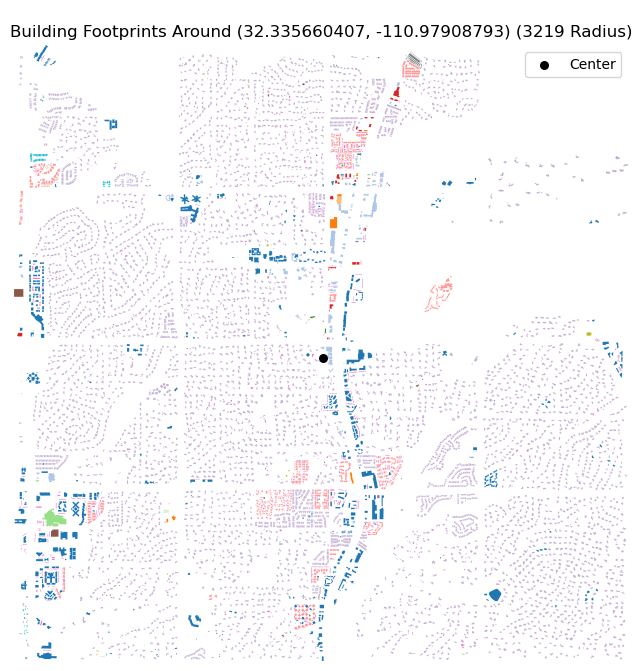

Buildings: 9536
Number of nodes (N): 1584
Number of edges (M): 3553


In [88]:
center_point2 = (32.335660407, -110.97908793)
plot_buildings(center_point2)
G2 = ox.graph_from_point(center_point2, dist=3219, network_type="drive")
N = G2.number_of_nodes()
M = G2.number_of_edges()

print("Number of nodes (N):", N)
print("Number of edges (M):", M)

1. Troy appears much denser near the center, with buildings closely packed together and fewer empty spaces.
2. Troy exhibits a clearer grid-like street pattern. Tucson shows more curvilinear and irregular street patterns 
3. In Troy, larger or distinct buildings are concentrated in the central corridor, Tucson commercial or larger buildings appear more scattered
4. Troy features a wider variety of housing types—represented in the diagram by a greater diversity of colors—whereas Tucson offers only a few monotonous types.
5. Troy reflects a traditional northeastern U.S. city structure, with dense development and compact blocks typical of older cities.
Tucson reflects a Southwestern suburban development style, characterized by lower density and larger spatial footprints.

In [83]:
def D(G, H):
    # 1) OSMnx graph -> undirected simple graph
    G_u = ox.convert.to_undirected(G)
    H_u = ox.convert.to_undirected(H)

    G_s = nx.Graph(G_u)
    H_s = nx.Graph(H_u)

    # 2) keep largest connected component
    G_s = G_s.subgraph(max(nx.connected_components(G_s), key=len)).copy()
    H_s = H_s.subgraph(max(nx.connected_components(H_s), key=len)).copy()

    # 3) average degree
    kG = sum(dict(G_s.degree()).values()) / G_s.number_of_nodes()
    kH = sum(dict(H_s.degree()).values()) / H_s.number_of_nodes()
    dk = abs(kG - kH) / (kG + kH)

    # 4) average clustering coefficient
    CG = nx.average_clustering(G_s)
    CH = nx.average_clustering(H_s)
    dC = abs(CG - CH)

    # 5) average shortest path length
    LG = nx.average_shortest_path_length(G_s)
    LH = nx.average_shortest_path_length(H_s)
    dL = abs(LG - LH) / (LG + LH)

    # 6) final dissimilarity
    return (dk + dC + dL) / 3

I define the dissimilarity between two road networks G and H as the average of three normalized differences: the difference in average degree, the difference in average clustering coefficient, and the difference in average shortest path length. Formally, This definition produces a single scalar value representing the structural dissimilarity between two road networks. $ \[
D(G,H)=
\frac{1}{3}
\left(
\frac{|\bar{k}_G-\bar{k}_H|}{\bar{k}_G+\bar{k}_H}
+
|C_G-C_H|
+
\frac{|L_G-L_H|}{L_G+L_H}
\right)
\]  $

The function
$D(G,H)$ uses the average degree, average clustering coefficient, and average shortest path length because these metrics capture different aspects of road network structure. The average degree reflects the typical connectivity of intersections, distinguishing grid-like networks from networks with many dead-ends or T-intersections. The clustering coefficient captures the presence of local loops and block structures, which are common in dense urban layouts.

The measure is size-comparable because the differences in average degree and shortest path length are normalized by the sum of the corresponding values, and the clustering coefficient is already bounded between 0 and 1. Therefore, the dissimilarity score does not depend directly on the number of nodes or edges, allowing networks of different sizes to be compared meaningfully.

In [89]:
print("D(G1, G2) =", D(G1, G2))

D(G1, G2) = 0.02660491597349628


Downloading: Atlanta, Georgia, USA
Downloading: Boston, MA, USA
Downloading: Buffalo, NY, USA
Downloading: Charlotte, NC, USA
Downloading: Chicago, IL, USA
Downloading: Cleveland, OH, USA
Downloading: Dallas, TX, USA
Downloading: Houston, TX, USA
Downloading: Denver, CO, USA
Downloading: Detroit, MI, USA
Downloading: Las Vegas, NV, USA
Downloading: Los Angeles, CA, USA
Downloading: Manhattan, NYC, NY, USA
Downloading: Miami, FL, USA
Downloading: Minneapolis, MN, USA
Downloading: Orlando, FL, USA
Downloading: Philadelphia, PA, USA
Downloading: Phoenix, AZ, USA
Downloading: Portland, OR, USA
Downloading: Sacramento, CA, USA
Downloading: San Francisco, CA, USA
Downloading: Seattle, WA, USA
Downloading: St. Louis, MO, USA
Downloading: Tampa, FL, USA
Downloading: Washington, District of Columbia, USA
Done pair (0, 0)
Done pair (0, 1)
Done pair (0, 2)
Done pair (0, 3)
Done pair (0, 4)
Done pair (0, 5)
Done pair (0, 6)
Done pair (0, 7)
Done pair (0, 8)
Done pair (0, 9)
Done pair (0, 10)
Done 

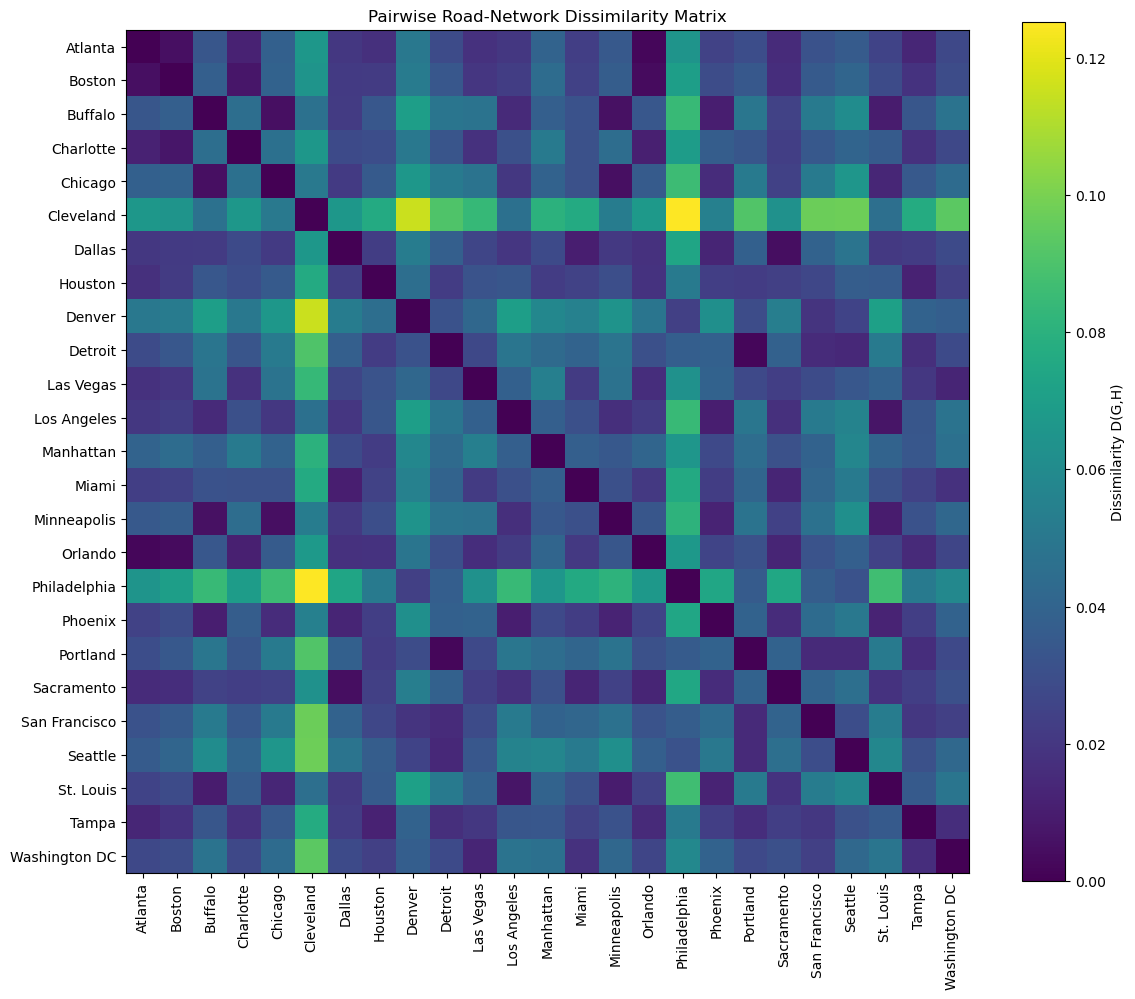

In [90]:
cities = [
    "Atlanta, Georgia, USA",
    "Boston, MA, USA",
    "Buffalo, NY, USA",
    "Charlotte, NC, USA",
    "Chicago, IL, USA",
    "Cleveland, OH, USA",
    "Dallas, TX, USA",
    "Houston, TX, USA",
    "Denver, CO, USA",
    "Detroit, MI, USA",
    "Las Vegas, NV, USA",
    "Los Angeles, CA, USA",
    "Manhattan, NYC, NY, USA",
    "Miami, FL, USA",
    "Minneapolis, MN, USA",
    "Orlando, FL, USA",
    "Philadelphia, PA, USA",
    "Phoenix, AZ, USA",
    "Portland, OR, USA",
    "Sacramento, CA, USA",
    "San Francisco, CA, USA",
    "Seattle, WA, USA",
    "St. Louis, MO, USA",
    "Tampa, FL, USA",
    "Washington, District of Columbia, USA"
]

# shorter labels for plotting
labels = [
    "Atlanta", "Boston", "Buffalo", "Charlotte", "Chicago",
    "Cleveland", "Dallas", "Houston", "Denver", "Detroit",
    "Las Vegas", "Los Angeles", "Manhattan", "Miami", "Minneapolis",
    "Orlando", "Philadelphia", "Phoenix", "Portland", "Sacramento",
    "San Francisco", "Seattle", "St. Louis", "Tampa", "Washington DC"
]

# -----------------------------
# 3. Build road networks
# -----------------------------
graphs = {}

for city in cities:
    print("Downloading:", city)
    center_point = ox.geocode(city)
    G = ox.graph_from_point(center_point, dist=3219, network_type="drive")
    graphs[city] = G

# -----------------------------
# 4. Compute distance matrix
# -----------------------------
n = len(cities)
dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):
        if i == j:
            dist_matrix[i, j] = 0.0
        else:
            d = D(graphs[cities[i]], graphs[cities[j]])
            dist_matrix[i, j] = d
            dist_matrix[j, i] = d
        print(f"Done pair ({i}, {j})")

print(dist_matrix)

# -----------------------------
# 5. Visualize with imshow
# -----------------------------
plt.figure(figsize=(12, 10))
im = plt.imshow(dist_matrix, cmap="viridis", interpolation="nearest")
plt.colorbar(im, label="Dissimilarity D(G,H)")

plt.xticks(range(n), labels, rotation=90)
plt.yticks(range(n), labels)

plt.title("Pairwise Road-Network Dissimilarity Matrix")
plt.tight_layout()
plt.show()